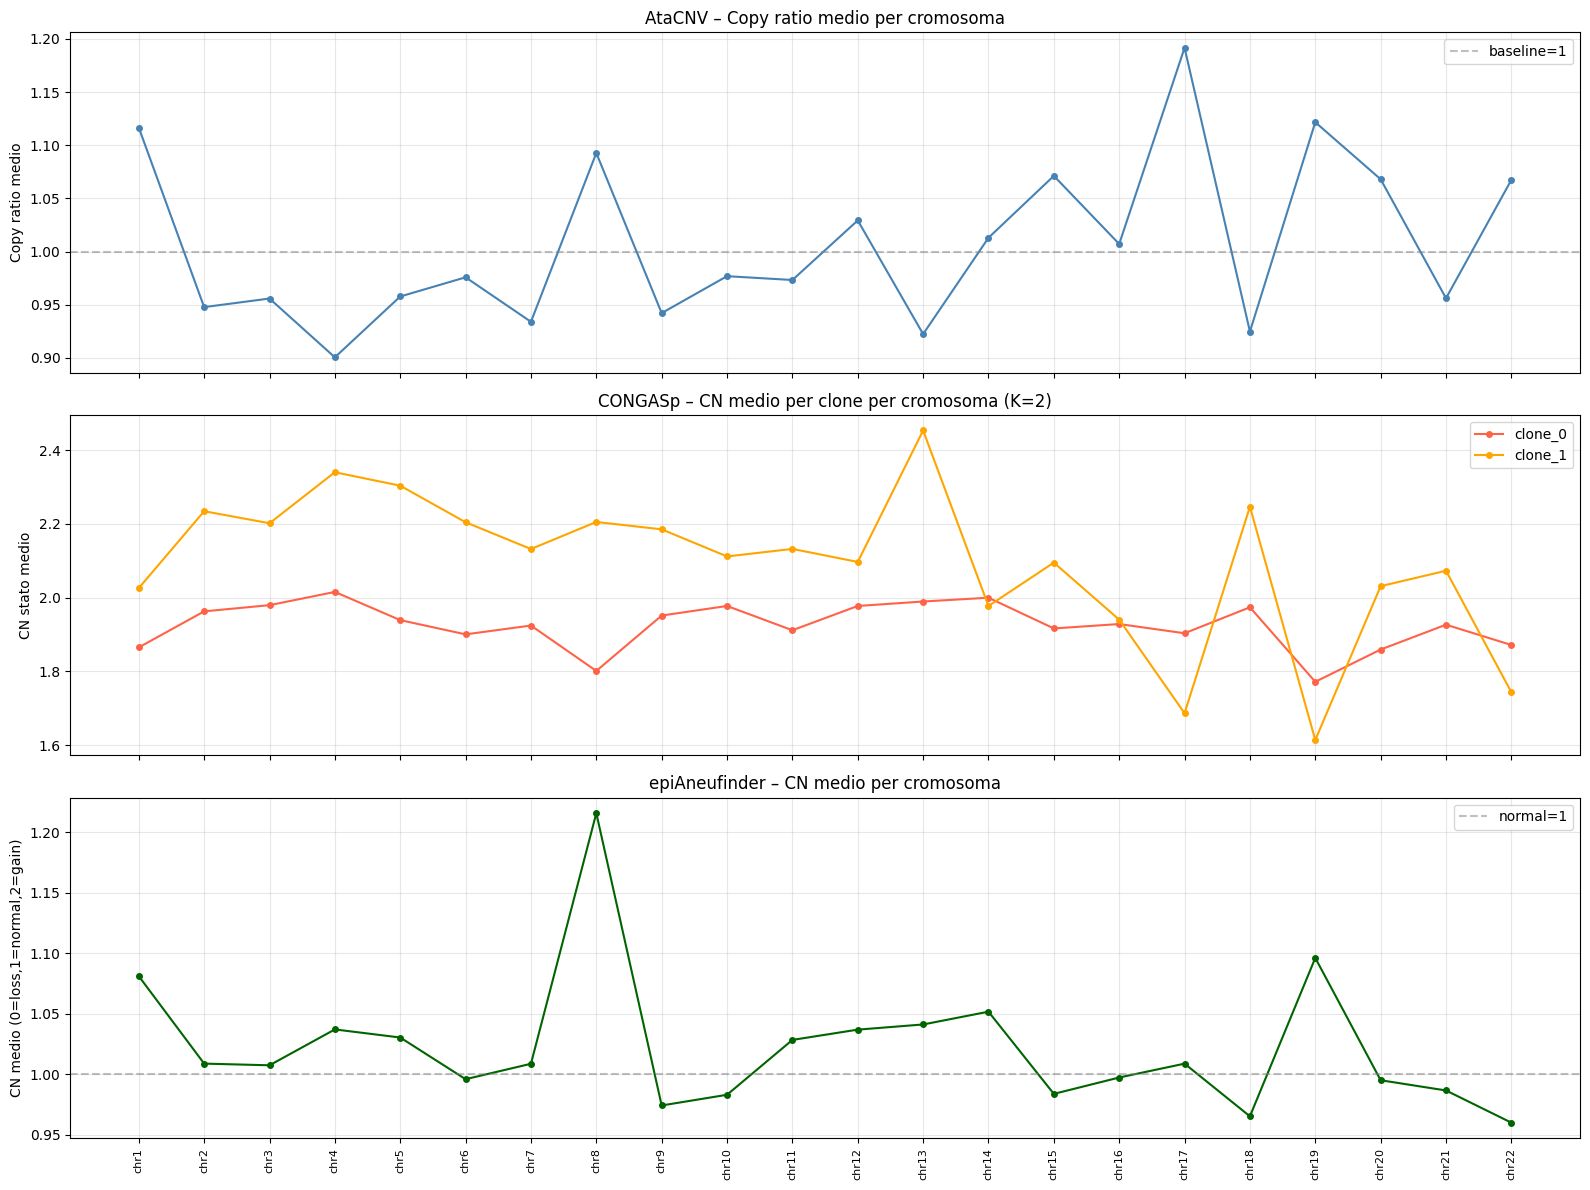

Salvato: comparison_3tools_DV90.png


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

chr_order = ["chr{}".format(i) for i in range(1, 23)]

# ── Carica dati ───────────────────────────────────────────
cnv_congas = pd.read_csv("/sharedFolder/Results/CONGAS_python/DV90/cnv_calls_K2.csv")
cr_atacnv  = pd.read_csv("/sharedFolder/Results/AtaCNV/DV90/cnv/copy_ratio.csv", index_col=0)
epi = pd.read_csv(
    "/sharedFolder/Results/epiAneufinder/DV90/epiAneufinder_results/results_table.tsv",
    sep=" ", header=0
)

# ── epiAneufinder ─────────────────────────────────────────
cell_cols_epi  = epi.columns[3:]
epi["mean_CN"] = epi[cell_cols_epi].mean(axis=1)
epi_chr = epi.groupby("seq")["mean_CN"].mean()
epi_chr = epi_chr.reindex([c for c in chr_order if c in epi_chr.index])

# ── AtaCNV ────────────────────────────────────────────────
cr_atacnv_chr = [c.split("_")[0] for c in cr_atacnv.columns]
cr_df  = pd.DataFrame({"chr": cr_atacnv_chr, "copy_ratio": cr_atacnv.mean(axis=0).values})
cr_chr = cr_df.groupby("chr")["copy_ratio"].mean()
cr_chr = cr_chr.reindex([c for c in chr_order if c in cr_chr.index])

# ── CONGASp ───────────────────────────────────────────────
clone_cols = [c for c in cnv_congas.columns if c.startswith("clone_")]
K = len(clone_cols)
cnv_chr = cnv_congas.groupby("chr")[clone_cols].mean()
cnv_chr = cnv_chr.reindex([c for c in chr_order if c in cnv_chr.index])

# ── Plot ──────────────────────────────────────────────────
colors = ["tomato", "orange", "steelblue"]
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(range(len(cr_chr)), cr_chr.values,
             color="steelblue", marker="o", linewidth=1.5, markersize=4)
axes[0].axhline(1.0, color="grey", linestyle="--", alpha=0.5, label="baseline=1")
axes[0].set_ylabel("Copy ratio medio")
axes[0].set_title("AtaCNV – Copy ratio medio per cromosoma")
axes[0].legend(); axes[0].grid(alpha=0.3)

for i, col in enumerate(clone_cols):
    axes[1].plot(range(len(cnv_chr)), cnv_chr[col].values,
                 color=colors[i], marker="o", linewidth=1.5,
                 markersize=4, label=col)
axes[1].set_ylabel("CN stato medio")
axes[1].set_title(f"CONGASp – CN medio per clone per cromosoma (K={K})")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(range(len(epi_chr)), epi_chr.values,
             color="darkgreen", marker="o", linewidth=1.5, markersize=4)
axes[2].axhline(1.0, color="grey", linestyle="--", alpha=0.5, label="normal=1")
axes[2].set_ylabel("CN medio (0=loss,1=normal,2=gain)")
axes[2].set_title("epiAneufinder – CN medio per cromosoma")
axes[2].set_xticks(range(len(epi_chr)))
axes[2].set_xticklabels(epi_chr.index, rotation=90, fontsize=8)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/sharedFolder/Results/comparison_3tools_DV90.png", dpi=150)
plt.show()
print("Salvato: comparison_3tools_DV90.png")

In [31]:
import numpy as np
import pandas as pd

# ── Soglie ────────────────────────────────────────────────
AMP_THR  = 1.05   # AtaCNV copy ratio > 1.05 = gain
DEL_THR  = 0.95   # AtaCNV copy ratio < 0.95 = loss
EPI_AMP  = 1.01   # epiAneufinder mean CN > 1.01 = gain
EPI_DEL  = 0.99   # epiAneufinder mean CN < 0.99 = loss
CON_AMP  = 3.1    # CONGASp CN medio cloni > 3.1 = gain
CON_DEL  = 2.5    # CONGASp CN medio cloni < 2.5 = loss

chr_order = ["chr{}".format(i) for i in range(1, 23)]

# ── Classificazione per tool ──────────────────────────────
def classify(val, amp_thr, del_thr):
    if pd.isna(val):      return "?"
    if val > amp_thr:     return "gain"
    if val < del_thr:     return "loss"
    return "neutral"

# AtaCNV
atac_cls = cr_chr.reindex(chr_order).apply(
    lambda v: classify(v, AMP_THR, DEL_THR))

# epiAneufinder
epi_cls = epi_chr.reindex(chr_order).apply(
    lambda v: classify(v, EPI_AMP, EPI_DEL))

# CONGASp: media tra i cloni
con_mean = cnv_chr.mean(axis=1).reindex(chr_order)
con_cls  = con_mean.apply(lambda v: classify(v, CON_AMP, CON_DEL))

# ── Tabella ───────────────────────────────────────────────
table = pd.DataFrame({
    "AtaCNV":       atac_cls.values,
    "CONGASp":      con_cls.values,
    "epiAneufinder": epi_cls.values,
}, index=chr_order)

# Accordo: quanti tool concordano sul tipo (gain/loss/neutral)
def agreement(row):
    calls = [v for v in row if v != "?"]
    if not calls: return "?"
    non_neutral = [v for v in calls if v != "neutral"]
    if not non_neutral: return "neutral"
    from collections import Counter
    most_common, count = Counter(non_neutral).most_common(1)[0]
    n = len(calls)
    if count == n:    return f"✅ {most_common} (3/3)"
    if count == n-1:  return f"⚠️ {most_common} (2/3)"
    return "❌ discordante"

table["Accordo"] = table.apply(agreement, axis=1)

print(table.to_string())

# Salva
table.to_csv("/sharedFolder/Results/CNV_comparison_table_DV90.csv")
print("\nSalvato: CNV_comparison_table_DV90.csv")

        AtaCNV CONGASp epiAneufinder        Accordo
chr1      gain    loss          gain  ⚠️ gain (2/3)
chr2      loss    loss       neutral  ⚠️ loss (2/3)
chr3   neutral    loss       neutral  ❌ discordante
chr4      loss    loss          gain  ⚠️ loss (2/3)
chr5   neutral    loss          gain  ❌ discordante
chr6   neutral    loss       neutral  ❌ discordante
chr7      loss    loss       neutral  ⚠️ loss (2/3)
chr8      gain    loss          gain  ⚠️ gain (2/3)
chr9      loss    loss          loss   ✅ loss (3/3)
chr10  neutral    loss          loss  ⚠️ loss (2/3)
chr11  neutral    loss          gain  ❌ discordante
chr12  neutral    loss          gain  ❌ discordante
chr13     loss    loss          gain  ⚠️ loss (2/3)
chr14  neutral    loss          gain  ❌ discordante
chr15     gain    loss          loss  ⚠️ loss (2/3)
chr16  neutral    loss       neutral  ❌ discordante
chr17     gain    loss       neutral  ❌ discordante
chr18     loss    loss          loss   ✅ loss (3/3)
chr19     ga

In [32]:
import numpy as np
import pandas as pd

df_dv90 = ccle['ABSOLUTE_combined.segtab'].copy()
df_dv90 = df_dv90[df_dv90['sample'] == 'DV90_LUNG'].copy()
df_dv90['chr'] = 'chr' + df_dv90['Chromosome'].astype(str)

chr_order = ["chr{}".format(i) for i in range(1, 23)]

# ── Mappa segmenti CCLE su bin 1Mb ────────────────────────
def map_ccle_to_bins(df_ccle, bin_size=1_000_000):
    rows = []
    for _, seg in df_ccle.iterrows():
        start_bin = (seg['Start'] // bin_size) * bin_size
        end_bin   = (seg['End']   // bin_size) * bin_size
        for b in range(int(start_bin), int(end_bin) + bin_size, bin_size):
            rows.append({
                'chr':    seg['chr'],
                'start':  b,
                'ccle_cn': seg['Modal_Total_CN']
            })
    return pd.DataFrame(rows)

ccle_bins = map_ccle_to_bins(df_dv90)
ccle_bins['ccle_call'] = ccle_bins['ccle_cn'].apply(
    lambda x: 'gain' if x > 2 else ('loss' if x < 2 else 'neutral'))

print(f"Bin CCLE totali: {len(ccle_bins)}")
print(ccle_bins['ccle_call'].value_counts())

# ── Prepara bin AtaCNV ─────────────────────────────────────
atac_bins = []
for col in cr_atacnv.columns:
    parts = col.split("_")
    atac_bins.append({
        'chr':   parts[0],
        'start': int(float(parts[1])),
        'atac_mean': cr_atacnv[col].mean()
    })
atac_df = pd.DataFrame(atac_bins)
atac_df['atac_call'] = atac_df['atac_mean'].apply(
    lambda x: 'gain' if x > 1.05 else ('loss' if x < 0.95 else 'neutral'))

# ── Prepara bin epiAneufinder ──────────────────────────────
cell_cols_epi  = epi.columns[3:]
epi["mean_CN"] = epi[cell_cols_epi].mean(axis=1)
epi["start"]   = (epi["start"] // 1_000_000) * 1_000_000
epi_bins = epi.groupby(["seq","start"])["mean_CN"].mean().reset_index()
epi_bins.columns = ['chr','start','epi_mean']
epi_bins['epi_call'] = epi_bins['epi_mean'].apply(
    lambda x: 'gain' if x > 1.01 else ('loss' if x < 0.99 else 'neutral'))

# ── Prepara bin CONGASp ────────────────────────────────────
clone_cols = [c for c in cnv_congas.columns if c.startswith("clone_")]
cnv_congas["con_mean"] = cnv_congas[clone_cols].mean(axis=1)
con_rows = []
for _, row in cnv_congas.iterrows():
    for b in range(int(row['start']), int(row['end']), 1_000_000):
        con_rows.append({'chr': row['chr'], 'start': b, 'con_mean': row['con_mean']})
con_df = pd.DataFrame(con_rows)
con_df['con_call'] = con_df['con_mean'].apply(
    lambda x: 'gain' if x > 2.1 else ('loss' if x < 1.9 else 'neutral'))

# ── Merge tutti su bin 1Mb ────────────────────────────────
merged = ccle_bins.merge(atac_df,  on=['chr','start'], how='inner') \
                  .merge(epi_bins, on=['chr','start'], how='inner') \
                  .merge(con_df,   on=['chr','start'], how='inner')

print(f"\nBin nel merge finale: {len(merged)}")
print(merged[['chr','start','ccle_call','atac_call','epi_call','con_call']].head(10))

Bin CCLE totali: 2885
ccle_call
neutral    2637
gain        217
loss         31
Name: count, dtype: int64

Bin nel merge finale: 2360
    chr     start ccle_call atac_call epi_call con_call
0  chr1   1000000   neutral      gain     loss     gain
1  chr1   3000000   neutral      gain     loss     loss
2  chr1   4000000   neutral      gain     loss     loss
3  chr1   5000000   neutral      gain  neutral  neutral
4  chr1   6000000   neutral      gain  neutral     loss
5  chr1   7000000   neutral      gain  neutral     loss
6  chr1   8000000   neutral      gain  neutral     loss
7  chr1   9000000   neutral      gain  neutral     loss
8  chr1  10000000   neutral      gain  neutral     loss
9  chr1  11000000   neutral      gain  neutral     loss



──────────────────── AtaCNV ────────────────────
              precision    recall  f1-score   support

        gain       0.26      0.87      0.40       185
        loss       0.01      0.24      0.02        29
     neutral       0.97      0.49      0.65      2146

    accuracy                           0.51      2360
   macro avg       0.42      0.53      0.36      2360
weighted avg       0.91      0.51      0.62      2360


──────────────────── epiAneufinder ────────────────────
              precision    recall  f1-score   support

        gain       0.15      0.87      0.26       185
        loss       0.03      0.59      0.06        29
     neutral       0.98      0.35      0.52      2146

    accuracy                           0.39      2360
   macro avg       0.39      0.60      0.28      2360
weighted avg       0.90      0.39      0.49      2360


──────────────────── CONGASp ────────────────────
              precision    recall  f1-score   support

        gain       0.07  

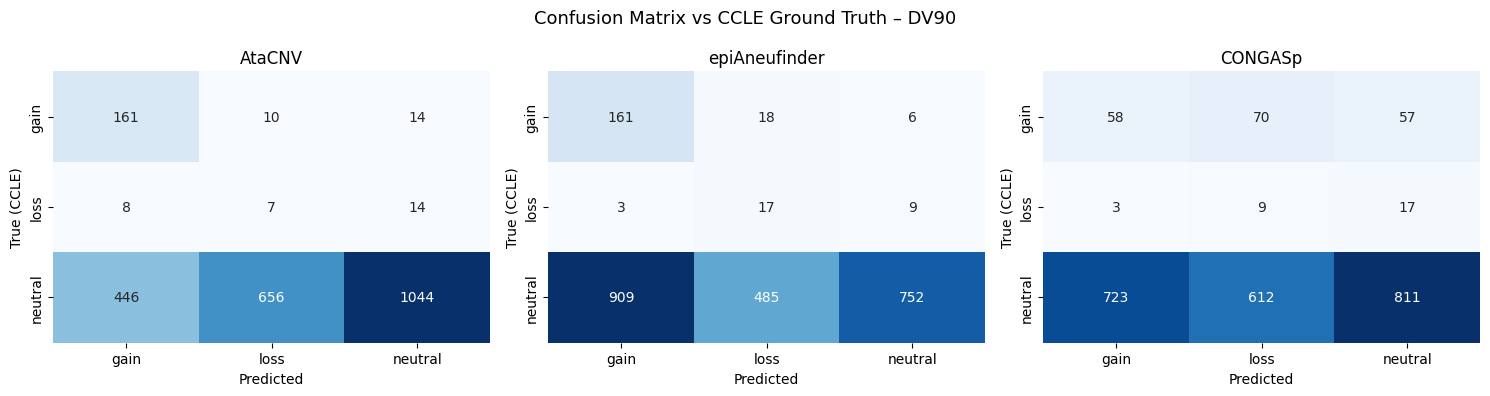

Salvato: confusion_matrix_DV90.png


In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

tools = {
    'AtaCNV':        'atac_call',
    'epiAneufinder': 'epi_call',
    'CONGASp':       'con_call',
}

# ── Metriche per ogni tool ────────────────────────────────
print("=" * 60)
for tool_name, col in tools.items():
    print(f"\n{'─'*20} {tool_name} {'─'*20}")
    print(classification_report(
        merged['ccle_call'], merged[col],
        labels=['gain','loss','neutral'],
        zero_division=0
    ))

# ── Tabella riassuntiva accuracy ──────────────────────────
rows = []
for tool_name, col in tools.items():
    correct = (merged['ccle_call'] == merged[col]).sum()
    total   = len(merged)
    
    # Per gain e loss separatamente
    for call in ['gain', 'loss']:
        mask = merged['ccle_call'] == call
        tp = ((merged['ccle_call'] == call) & (merged[col] == call)).sum()
        fn = ((merged['ccle_call'] == call) & (merged[col] != call)).sum()
        fp = ((merged['ccle_call'] != call) & (merged[col] == call)).sum()
        tn = ((merged['ccle_call'] != call) & (merged[col] != call)).sum()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        rows.append({
            'Tool': tool_name, 'CNA_type': call,
            'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
            'Sensitivity': round(sens, 3),
            'Specificity': round(spec, 3),
        })

summary = pd.DataFrame(rows)
print("\n=== Tabella Performance vs CCLE Ground Truth ===")
print(summary.to_string(index=False))
summary.to_csv("/sharedFolder/Results/performance_vs_CCLE_DV90.csv", index=False)

# ── Heatmap confusion matrix ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['gain', 'loss', 'neutral']
for ax, (tool_name, col) in zip(axes, tools.items()):
    cm = confusion_matrix(merged['ccle_call'], merged[col], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=labels, yticklabels=labels,
                cmap='Blues', cbar=False)
    ax.set_title(f"{tool_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True (CCLE)")

plt.suptitle("Confusion Matrix vs CCLE Ground Truth – DV90", fontsize=13)
plt.tight_layout()
plt.savefig("/sharedFolder/Results/confusion_matrix_DV90.png", dpi=150)
plt.show()
print("Salvato: confusion_matrix_DV90.png")